In [1]:
# phase1_mode_sweep.py
# MPB: neff vs. waveguide width for 300 nm X-cut TFLN strip at 1550 nm
# Reference geometry: [R1], [R4], [R5]

#notes to self, MPB was first created for another intended purpose than integrated photonics, so slight change in terminilogy or variables
# k here is beta (wavevector)
# Neff in lec --> beta / k0
#Bands here refer to modes
# MPB defines things with cycles instead of radians so beta = 2*pi*kz
#plane waves deifinition here is ~ e^(j2*pi*Kz*z) so kz = 1/lambda guide
# we studied ~ e^(j beta*z) and beta = (2 pi)/lambda guide


In [2]:

from meep import mpb
import meep as mp
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

Using MPI version 4.1, 1 processes


In [3]:
# ── Units: µm throughout; c = 1 ────────────────────────────────────────────
lam = 1.55          # µm
f0  = 1.0 / lam    # = 0.6452 in MEEP units (a = 1 µm, c = 1)

# ── Material indices at 1550 nm (Zelmon et al. 1997 [R5]) ──────────────────
n_e  = 2.138   # LNO extraordinary (TE mode, X-cut: c-axis along x)
n_o  = 2.211   # LNO ordinary
n_ox = 1.444   # SiO₂ BOX
n_air = 1.0

In [4]:
def lno_medium():
    """X-cut LNO: extraordinary along x → epsilon_xx = ne^2, yy = zz = no^2"""
    return mp.Medium(epsilon_diag=mp.Vector3(n_e**2, n_o**2, n_o**2))

# ── Supercell (cross-section in x-y; z = propagation direction) ────────────
sx = 6.0   # x-span (µm) — must be >> wg width for PML-like confinement
sy = 5.5   # y-span (µm) — must contain BOX + LNO + air above
h  = 0.30  # LNO thickness

# BOX sits below LNO center:  y_center_BOX = -(h/2 + BOX_thickness/2)
# Air above LNO: default background


In [5]:

def run_mpb(w, h=0.3, resolution=64, verbose=False):
    """
    Solve for guided modes of a strip waveguide of width w (µm).
    Returns list of neff values at 1550 nm.
    """
    geometry = [
        # SiO₂ BOX — placed below LNO layer center (y=0 = LNO center)
        mp.Block(
            size=mp.Vector3(sx, 2.5, mp.inf),
            center=mp.Vector3(0, -(h/2 + 1.25), 0),
            material=mp.Medium(index=n_ox)
        ),
        # LNO waveguide core
        mp.Block(
            size=mp.Vector3(w, h, mp.inf),
            center=mp.Vector3(0, 0, 0),
            material=lno_medium()
        ),
    ]
    # Default background = air (n=1)

    ms = mpb.ModeSolver(
        geometry_lattice=mp.Lattice(size=mp.Vector3(sx, sy, 0)),
        geometry=geometry,
        resolution=resolution,  # 64 pts/µm → ~16 nm sampling in core
        num_bands=4,            # look for up to 4 guided modes
        default_material=mp.Medium(index=n_ox),
    )

    if not verbose:
        ms.filename_prefix = 'tmp'

    # find_k: at fixed frequency f0, find k_z for each guided band
    # Lower bound: k_z > n_ox * f0 (mode must be above BOX cutoff)
    # Upper bound: k_z < n_e  * f0 (mode must be below core index)
    neff_vals = []
    
    for mode_n in range (1,5):
        try:
            k_pts = ms.find_k(
                mp.NO_PARITY,           # allow all parities
                f0,                     # target frequency (in MEEP units)
                mode_n, mode_n,                   # band range: 1 to 4
                mp.Vector3(0, 0, 1),    # propagation along z
                1e-4,                   # convergence tolerance
                kmag_guess=f0 * ((n_e + n_ox) / 2), # **NEW: Initial guess**
                kmag_min=f0 * n_ox,       # k lower bound (BOX cutoff)
                kmag_max=f0 * n_e,        # k upper bound (Core index)
                # f0 * n_ox,              # k lower bound
                # f0 * n_e,               # k upper bound
            )

            if k_pts and k_pts[0] > f0 * n_ox:
                neff_vals.append(k_pts[0] / f0)

            # # neff = k_z / f0  (since λ = 1/f0 in units where c = 1)
            # # neff_vals = []
            # for k in k_pts:
            #     if k.z > f0 * n_ox:  # only guided modes (above BOX)
            #         neff_vals.append(k.z / f0)

            # return neff_vals

        except ValueError:
            break

    return neff_vals



In [6]:

def compute_ng(w, delta_lam=0.01):
    """
    Group index ng = neff - λ × d(neff)/dλ
    Estimated via central finite difference over ±delta_lam around 1550 nm.
    """
    global f0, lam

    lam_lo = lam - delta_lam
    lam_hi = lam + delta_lam

    # Temporarily change f0 for each wavelength
    f0_lo = 1.0 / lam_lo
    f0_hi = 1.0 / lam_hi
    f0_0  = 1.0 / lam

    def _get_neff_at_f(f):
        """Run MPB at a different frequency."""
        # (In practice, recreate ModeSolver with new f; shortened here)
        ms = mpb.ModeSolver(
            geometry_lattice=mp.Lattice(size=mp.Vector3(sx, sy, 0)),
            geometry=[
                mp.Block(mp.Vector3(sx, 2.5, mp.inf),
                         center=mp.Vector3(0, -(h/2 + 1.25), 0),
                         material=mp.Medium(index=n_ox)),
                mp.Block(mp.Vector3(w, h, mp.inf),
                         center=mp.Vector3(0, 0, 0),
                         material=lno_medium()),
            ],
            resolution=64, num_bands=2,
            default_material=mp.Medium(index=n_ox),
        )
        k_pts = ms.find_k(mp.NO_PARITY, f, 1, 2, mp.Vector3(0,0,1),
                          1e-4, 
                        #   f*n_ox, f*n_e,
                          kmag_guess=f * ((n_e + n_ox) / 2), # **NEW: Initial guess**
                          kmag_min=f * n_ox,       # k lower bound (BOX cutoff)
                          kmag_max=f * n_e, #
                          
                          )
        if k_pts and k_pts[0] > f * n_ox:
            return k_pts[0] / f
        return None

    neff_lo = _get_neff_at_f(f0_lo)
    neff_hi = _get_neff_at_f(f0_hi)
    neff_0  = _get_neff_at_f(f0_0)

    if None in (neff_lo, neff_hi, neff_0):
        return None, None

    dneff_dlam = (neff_hi - neff_lo) / (2 * delta_lam)
    ng = neff_0 - lam * dneff_dlam
    return ng, neff_0


In [7]:
# # ── Width sweep ─────────────────────────────────────────────────────────────
# widths = np.arange(0.6, 1.45, 0.1)   # 0.6 to 1.4 µm in 0.1 steps
# results = []

# if mp.am_master():
#     print(f"{'w (µm)':>8}  {'neff_1':>8}  {'neff_2':>8}  {'# modes':>8}")
# for w in widths:
#     neff_list = run_mpb(w, resolution=64, verbose=False)
#     n1 = neff_list[0] if len(neff_list) > 0 else None
#     n2 = neff_list[1] if len(neff_list) > 1 else None
#     n_modes = len(neff_list)
#     results.append({'w': w, 'neff1': n1, 'neff2': n2, 'n_modes': n_modes})
#     if mp.am_master():
#         print(f"{w:>8.2f}  {str(round(n1,4)) if n1 else 'none':>8}  "
#           f"{str(round(n2,4)) if n2 else 'none':>8}  {n_modes:>8}")


In [8]:
# ── Width sweep incl. neff 3─────────────────────────────────────────────────────────────

# ── Width sweep ─────────────────────────────────────────────────────────────
widths = np.arange(0.6, 1.45, 0.1)   # 0.6 to 1.4 µm in 0.1 steps
results = []

if mp.am_master():
    print(f"{'w (µm)':>8}  {'neff_1':>8}  {'neff_2':>8}  {'neff_3':>8}  {'# modes':>8}")

for w in widths:
    # Explicitly using h=0.30 for safety!
    neff_list = run_mpb(w, h=0.30, resolution=64, verbose=False) 
    
    n1 = neff_list[0] if len(neff_list) > 0 else None
    n2 = neff_list[1] if len(neff_list) > 1 else None
    n3 = neff_list[2] if len(neff_list) > 2 else None  # Grab Mode 3
    n_modes = len(neff_list)
    
    # Save n3 to the results dictionary
    results.append({'w': w, 'neff1': n1, 'neff2': n2, 'neff3': n3, 'n_modes': n_modes})
    
    if mp.am_master():
        print(f"{w:>8.2f}  {str(round(n1,4)) if n1 else 'none':>8}  "
              f"{str(round(n2,4)) if n2 else 'none':>8}  "
              f"{str(round(n3,4)) if n3 else 'none':>8}  {n_modes:>8}")


  w (µm)    neff_1    neff_2    neff_3   # modes
Initializing eigensolver data
Computing 1 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 384 x 360 x 1.
Solving for 1 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (6, 0, 0)
     (0, 5.5, 0)
     (0, 0, 1)
Cell volume = 33
Reciprocal lattice vectors (/ 2 pi):
     (0.166667, -0, 0)
     (-0, 0.181818, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,-1.4,0)
          size (6,2.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (0.6,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 2 and 5 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: .
Initializing fields to random numbers...
1 k-points
  Vector3<0.0, 0.0, 1.155483870967742>
elapsed time for initialization: 0.07531118392944336
solve_kpoint (0,0,1.15548):
freqs:, k index, k1

In [9]:
# ── Find Exact Cutoff Width for Mode 2 - h=0.3 (Bisection Search) ───────────────────
w_cutoff_3 = None
if mp.am_master():
    print("\n--- Starting bisection search for Mode 3 cutoff ---")

# Define our search bounds based on typical TFLN behavior 
# (You can dynamically grab this from your previous sweep if you prefer)
w_min = 0.2  
w_max = 1.5
tol = 1e-3   # Accuracy of 1 nm for the waveguide width

# First check if mode 3 even exists at w_max to avoid infinite loops
test_modes = run_mpb(w=w_max, h=0.3 ,resolution=64, verbose=False)
if len(test_modes) >= 3:
    while (w_max - w_min) > tol:
        w_mid = (w_min + w_max) / 2.0
        modes = run_mpb(w=w_mid, h=0.3 ,resolution=64, verbose=False)
        
        if len(modes) >= 3:
            w_max = w_mid  # Cutoff is at a narrower width
        else:
            w_min = w_mid  # Cutoff is at a wider width

    w_cutoff_3 = (w_min + w_max) / 2.0
    if mp.am_master():
        print(f"Exact Mode 3 cutoff found at w = {w_cutoff_3:.4f} µm")
else:
    if mp.am_master():
        print("Mode 3 does not exist even at max width. Increase w_max.")


--- Starting bisection search for Mode 3 cutoff ---
Initializing eigensolver data
Computing 1 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 384 x 360 x 1.
Solving for 1 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (6, 0, 0)
     (0, 5.5, 0)
     (0, 0, 1)
Cell volume = 33
Reciprocal lattice vectors (/ 2 pi):
     (0.166667, -0, 0)
     (-0, 0.181818, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,-1.4,0)
          size (6,2.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (1.5,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 2 and 5 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: .
Initializing fields to random numbers...
1 k-points
  Vector3<0.0, 0.0, 1.155483870967742>
elapsed time for initialization: 0.07465147972106934
solve_kpoint (0,0,1.15548):
freqs:, k index

In [10]:
# ── Group index at design width  ─────────────────────────────────────────────

# new_width_1mode = w_cutoff_3 - 0.05
new_width_1mode_per_polarization = 0.9

ng, neff_design = compute_ng(new_width_1mode_per_polarization)

# if mp.am_master():
#     print(f"\nAt w = {new_width_1mode:.4f} µm: neff = {neff_design:.4f}, ng = {ng:.4f}")

if mp.am_master():
    if ng is not None and neff_design is not None:
        print(f"\nAt w = {new_width_1mode_per_polarization:.4f} µm: neff = {neff_design:.4f}, ng = {ng:.4f}")
    else:
        print(f"\nAt w = {new_width_1mode_per_polarization:.4f} µm: No guided mode found.")

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 384 x 360 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (6, 0, 0)
     (0, 5.5, 0)
     (0, 0, 1)
Cell volume = 33
Reciprocal lattice vectors (/ 2 pi):
     (0.166667, -0, 0)
     (-0, 0.181818, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,-1.4,0)
          size (6,2.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (0.9,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 2 and 5 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: .
Initializing fields to random numbers...
1 k-points
  Vector3<0.0, 0.0, 1.162987012987013>
elapsed time for initialization: 0.07670354843139648
solve_kpoint (0,0,1.16299):
freqs:, k index, k1, k2, k3, kmag/2pi, band 1, band 2
Solving for ba

In [11]:

# # ── Save for INTERCONNECT and Lumerical ─────────────────────────────────────
# if mp.am_master():
#     w_arr    = np.array([r['w']    for r in results])
#     neff_arr = np.array([r['neff1'] for r in results], dtype=float)

#     scipy.io.savemat('neff_vs_width.mat', {
#         'widths': w_arr,
#         'neff':   neff_arr,
#         'ng_design': ng,
#         'neff_design': neff_design,
#     })
#     print("Saved: neff_vs_width.mat")

#     # ── Plot ─────────────────────────────────────────────────────────────────────
#     plt.figure(figsize=(7, 4))
#     plt.plot(w_arr, neff_arr, 'b-o', label='neff TE00')
#     plt.axvline(0.9, color='gray', linestyle='--', label='w = 0.9 µm')
#     plt.xlabel('Waveguide width (µm)')
#     plt.ylabel('Effective index neff')
#     plt.title('neff vs. Width — 300 nm X-cut TFLN Strip (MPB)')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig('neff_vs_width.png', dpi=150)
#     plt.close()

In [12]:
# #extra saving after w cutoff thing

# if mp.am_master():
#     w_arr    = np.array([r['w']    for r in results])
#     neff1_arr = np.array([r['neff1'] for r in results], dtype=float)
    
#     # Replace None with NaN for MATLAB compatibility
#     neff2_arr = np.array([r['neff2'] if r['neff2'] is not None else np.nan for r in results], dtype=float)

#     save_dict = {
#         'widths': w_arr,
#         'neff1':  neff1_arr,
#         'neff2':  neff2_arr,
#         'ng_design': ng if ng is not None else np.nan,
#         'neff_design': neff_design if neff_design is not None else np.nan,
#     }
    
#     # Only save cutoff if we successfully found it
#     if w_cutoff_3 is not None:
#         save_dict['w_cutoff_mode2'] = w_cutoff_3

#     scipy.io.savemat('ext_neff_vs_width.mat', save_dict)
#     print("Saved: ext_neff_vs_width.mat")


#     # ── Plot ─────────────────────────────────────────────────────────────────────
#     plt.figure(figsize=(8, 5))
    
#     # Plot Mode 1 and Mode 2
#     plt.plot(w_arr, neff1_arr, 'b-o', label='neff Mode 1')
    
#     # Use markers for Mode 2, but drop NaNs so matplotlib draws it cleanly
#     valid_idx = ~np.isnan(neff2_arr)
#     plt.plot(w_arr[valid_idx], neff2_arr[valid_idx], 'r-s', label='neff Mode 2')

#     # Plot lines for design width and newly found cutoff
#     plt.axvline(0.9, color='gray', linestyle='--', label='Design w = 0.9 µm')
#     if w_cutoff is not None:
#         plt.axvline(w_cutoff, color='red', linestyle=':', linewidth=2, 
#                     label=f'Mode 2 Cutoff ({w_cutoff:.3f} µm)')
    
#     # Plot the BOX substrate index limit
#     plt.axhline(n_ox, color='black', linestyle='-', alpha=0.5, label='Substrate Index (Cutoff limit)')

#     plt.xlabel('Waveguide width (µm)')
#     plt.ylabel('Effective index (neff)')
#     plt.title('neff vs. Width — 300 nm X-cut TFLN Strip')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig('ext_neff_vs_width.png', dpi=150)
#     plt.close()

In [16]:
# ── Save and Plot with cutoff mode 3 ────────────────────────────────────────────────────────────
if mp.am_master():
    w_arr     = np.array([r['w']     for r in results])
    neff1_arr = np.array([r['neff1'] for r in results], dtype=float)
    
    # Replace None with NaN for MATLAB compatibility
    neff2_arr = np.array([r['neff2'] if r['neff2'] is not None else np.nan for r in results], dtype=float)
    neff3_arr = np.array([r['neff3'] if r['neff3'] is not None else np.nan for r in results], dtype=float)

    save_dict = {
        'widths': w_arr,
        'neff1':  neff1_arr,
        'neff2':  neff2_arr,
        'neff3':  neff3_arr,
        'ng_design': ng if ng is not None else np.nan,
        'neff_design': neff_design if neff_design is not None else np.nan,
    }
    
    if w_cutoff_3 is not None:
        save_dict['w_cutoff_mode3'] = w_cutoff_3

    scipy.io.savemat('ext_neff_vs_width_3.mat', save_dict)
    print("Saved: ext_neff_vs_width_3.mat")


    # ── Plot ─────────────────────────────────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    
    # Plot Mode 1
    plt.plot(w_arr, neff1_arr, 'b-o', label='neff Mode 1 (TE00)')
    
    # Plot Mode 2 (Filter out NaNs)
    valid_idx2 = ~np.isnan(neff2_arr)
    plt.plot(w_arr[valid_idx2], neff2_arr[valid_idx2], 'r-s', label='neff Mode 2 (TM00)')

 # //////////////////////////////////////////////////////////////-----
    # Plot Mode 3 (Filter out NaNs)
    valid_idx3 = ~np.isnan(neff3_arr)
    # plt.plot(w_arr[valid_idx3], neff3_arr[valid_idx3], 'g-^', label='neff Mode 3 (TE10)')
    # Plot Mode 3: Add the exact cutoff point so it visually touches the line!
    valid_idx3 = ~np.isnan(neff3_arr)
    w_mode3 = w_arr[valid_idx3]
    n_mode3 = neff3_arr[valid_idx3]
    
    if w_cutoff_3 is not None:
        # Insert the exact cutoff point at the beginning of the arrays.
        # At cutoff, neff is exactly equal to the substrate index (n_ox).
        w_mode3 = np.insert(w_mode3, 0, w_cutoff_3)
        n_mode3 = np.insert(n_mode3, 0, n_ox)

    plt.plot(w_mode3, n_mode3, 'g-^', label='neff Mode 3 (TE10)')
    # //////////////////////////////////////////////////////////////-----



    # Plot lines for design width and newly found cutoff
    plt.axvline(0.9, color='gray', linestyle='--', label='Design w = 0.9 µm')
    
    if w_cutoff_3 is not None:
        plt.axvline(w_cutoff_3, color='red', linestyle=':', linewidth=2, 
                    label=f'Mode 3 Cutoff ({w_cutoff_3:.4f} µm)')
    
    # Plot the BOX substrate index limit
    plt.axhline(n_ox, color='black', linestyle='-', alpha=0.5, label='Substrate Index (Cutoff limit)')

    plt.xlabel('Waveguide width (µm)')
    plt.ylabel('Effective index ($n_{eff}$)')
    plt.title('Dispersion Curve: 300 nm X-cut TFLN Strip')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('ext_neff_vs_width_3_2.png', dpi=150)
    plt.close()

Saved: ext_neff_vs_width_3.mat


In [17]:
def export_3d_structure(w):
    """
    Creates a temporary 3D MEEP simulation and exports the geometry
    to an HDF5 file for viewing in ParaView.
    """
    geometry = [
        mp.Block(size=mp.Vector3(sx, 2.5, mp.inf),
                 center=mp.Vector3(0, -(h/2 + 1.25), 0),
                 material=mp.Medium(index=n_ox)),
        mp.Block(size=mp.Vector3(w, h, mp.inf),
                 center=mp.Vector3(0, 0, 0),
                 material=lno_medium()),
    ]
    
    # Give it an arbitrary Z-length (e.g., 5 µm) to create a 3D volume
    sim = mp.Simulation(
        cell_size=mp.Vector3(sx, sy, 5.0),
        geometry=geometry,
        resolution=32, # Lower resolution to keep file size small
        default_material=mp.Medium(index=n_ox)
    )

    # Initialize and output the epsilon data to an .h5 file
    # sim.init_sim()
    # sim.output_epsilon()

    sim.run(mp.output_epsilon, until=0)
    
    if mp.am_master():
        print("Exported 3D geometry to 'eps-000000.00.h5'.")
        print("Download this file and open it in ParaView to view the 3D structure.")

# Call this at the bottom of your script:
export_3d_structure(0.9)

-----------
Initializing structure...
time for choose_chunkdivision = 1.5108e-05 s
Working in 3D dimensions.
Computational cell is 6 x 5.5 x 5 with resolution 32
     block, center = (0,-1.4,0)
          size (6,2.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.08514,2.08514,2.08514)
     block, center = (0,0,0)
          size (0.9,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
time for set_epsilon = 12.7906 s
-----------
creating output file "./eps-000000.00.h5"...
run 0 finished at t = 0.0 (0 timesteps)
Exported 3D geometry to 'eps-000000.00.h5'.
Download this file and open it in ParaView to view the 3D structure.


['eps']


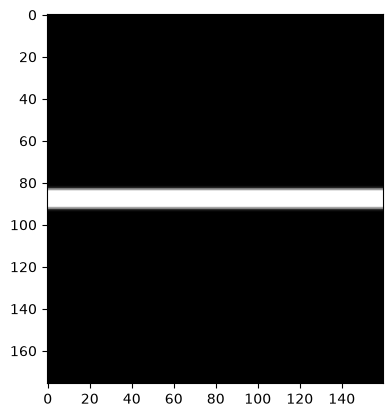

In [20]:
import h5py
import matplotlib.pyplot as plt

# 1. Open the H5 file
with h5py.File('eps-000000.00.h5', 'r') as f:
    # Print keys to find your 3D dataset name
    print(list(f.keys())) 
    
    # 2. Extract the 3D dataset as a array
    data_3d = f['eps'][:] 

# 3. View the middle slice along the first axis
middle_slice = data_3d.shape[0] // 2
plt.imshow(data_3d[middle_slice, :, :], cmap='gray')
plt.show()

In [24]:
def check_mpb_geometry(w, h=0.30):
    """
    Forces MPB to initialize the geometry and exports the exact 
    dielectric (epsilon) grid to a PNG image.
    """
    geometry = [
        mp.Block(size=mp.Vector3(sx, 2.5, mp.inf),
                 center=mp.Vector3(0, -(h/2 + 1.25), 0),
                 material=mp.Medium(index=n_ox)),
        mp.Block(size=mp.Vector3(w, h, mp.inf),
                 center=mp.Vector3(0, 0, 0),
                 material=lno_medium()),
    ]
    
    ms = mpb.ModeSolver(
        geometry_lattice=mp.Lattice(size=mp.Vector3(sx, sy, 0)),
        geometry=geometry,
        resolution=64, # Your actual sweep resolution
        default_material=mp.Medium(index=n_ox)
    )
    
    # Initialize the grid WITHOUT solving for modes
    ms.init_params(mp.NO_PARITY, True)
    
    # Extract the actual epsilon matrix the solver sees
    eps = ms.get_epsilon()
    
    # Plot it
    plt.figure(figsize=(7, 6))
    # Transpose because MEEP internal arrays are [x, y, z]
    plt.imshow(eps.transpose(), interpolation='nearest', cmap='viridis', origin='lower',
               extent=[-sx/2, sx/2, -sy/2, sy/2])
    
    plt.title(f'MPB Internal Epsilon Grid (w={w}µm, res=64)')
    plt.xlabel('X (µm)')
    plt.ylabel('Y (µm)')
    plt.colorbar(label='Dielectric Constant ($\epsilon$)')
    plt.tight_layout()
    
    plt.savefig('mpb_geometry_check.png', dpi=150)
    plt.close()
    
    if mp.am_master():
        print("Saved MPB exact geometry grid to 'mpb_geometry_check.png'.")

# Call this at the bottom:
check_mpb_geometry(0.9)

Working in 2 dimensions.
Grid size is 384 x 360 x 1.
Solving for 1 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (6, 0, 0)
     (0, 5.5, 0)
     (0, 0, 1)
Cell volume = 33
Reciprocal lattice vectors (/ 2 pi):
     (0.166667, -0, 0)
     (-0, 0.181818, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,-1.4,0)
          size (6,2.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (0.9,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 2 and 5 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: .
Initializing fields to random numbers...
epsilon: 2.08514-4.88852, mean 2.10803, harm. mean 2.09522, 100% > 1, 0.816655% "fill"


<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_40056/3342713243.py:37: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(label='Dielectric Constant ($\epsilon$)')


Saved MPB exact geometry grid to 'mpb_geometry_check.png'.


In [26]:
!conda install -c conda-forge h5utils -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/codespace/miniconda/envs/popa

  added / updated specs:
    - h5utils


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    h5utils-1.13.2             |nompi_hd56284f_1107          70 KB  conda-forge
    ------------------------------------------------------------
                                           Total:          70 KB

The following NEW packages will be INSTALLED:

  h5utils            conda-forge/linux-64::h5utils-1.13.2-nompi_hd56284f_1107 



                                                                                
Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [27]:
!h5tovtk eps-000000.00.h5